# Занятие 02. Регрессия по внешнему набору данных: Zenodo PMSM inverter fault diagnosis

## Теоретический блок

Регрессия (regression) - задача прогнозирования непрерывной величины.
В данном блокноте прогнозируется максимальная температура полумоста инвертора. Для
временных или профильных инженерных данных особенно важен способ проверки:
случайное перемешивание соседних точек может завысить качество модели.
Поэтому используется holdout-разбиение по группам, то есть часть профилей
полностью откладывается в тестовую выборку.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
DATASET_ID = "zenodo_pmsm_inverter_fault"
DATASET_TITLE = "Zenodo PMSM inverter fault diagnosis"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    return data.index[~test_mask], data.index[test_mask], test_groups


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/zenodo_pmsm_inverter_fault_features.csv
Размер feature-таблицы: (10892, 11)


,sample_id,profile_id,time_index,speed_rpm,torque_proxy_nm,voltage_v,current_a,ambient_temp_c,temperature_c,max_bridge_temp_c,is_allowed
0,1,1,0.0,95.492966,5.642229,21.994135,6.118761,25.0,11.430371,12.229922,1
1,2,1,0.1,95.492966,5.587977,21.994135,6.126954,25.0,11.954090,12.646151,1
2,3,1,0.2,95.492966,12.912023,21.994135,6.078809,25.0,11.430230,12.229922,1
3,4,1,0.3,95.492966,9.042033,21.994135,6.039383,25.0,11.843363,12.479497,1
4,5,1,0.4,95.492966,5.533724,17.106549,6.022350,25.0,11.320267,12.229922,1


In [2]:
regression_features = ['speed_rpm', 'torque_proxy_nm', 'voltage_v', 'current_a', 'ambient_temp_c']
regression_target = 'max_bridge_temp_c'
forbidden_regression_features = set(['max_bridge_temp_c', 'T1', 'T2', 'T3', 'is_allowed'])
leaked_regression_features = forbidden_regression_features & set(regression_features)
if leaked_regression_features:
    raise AssertionError(
        "Обнаружена утечка данных в regression_features: "
        f"{sorted(leaked_regression_features)}"
    )

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

model_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=regression_features + [regression_target]
).copy()
train_idx, test_idx, test_groups = group_holdout_split(model_df, GROUP_COLUMN, test_share=0.25)
X_train = model_df.loc[train_idx, regression_features]
X_test = model_df.loc[test_idx, regression_features]
y_train = model_df.loc[train_idx, regression_target]
y_test = model_df.loc[test_idx, regression_target]

print("Тестовые группы:", test_groups)
print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)


Тестовые группы: [7 8 9]
Обучающая выборка: (7269, 5)
Тестовая выборка: (3623, 5)


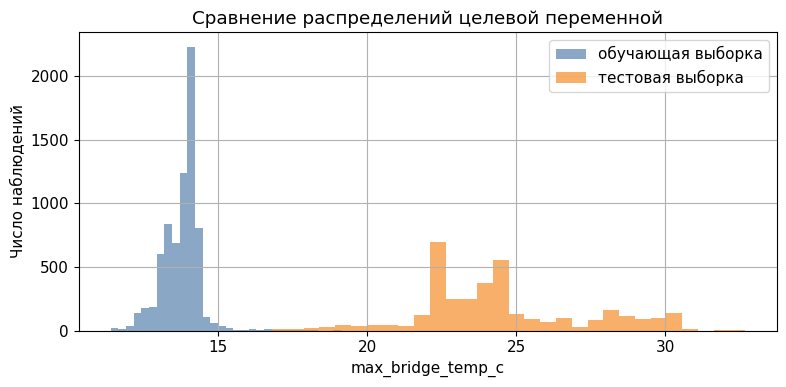

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=30, alpha=0.65, label="обучающая выборка", color="#4c78a8")
ax.hist(y_test, bins=30, alpha=0.65, label="тестовая выборка", color="#f58518")
ax.set_xlabel(regression_target)
ax.set_ylabel("Число наблюдений")
ax.set_title("Сравнение распределений целевой переменной")
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }

models = {
    "mean_baseline": None,
    "linear_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "polynomial_ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
}

predictions = {}
rows = []
for name, model in models.items():
    if model is None:
        y_pred = np.full(len(y_test), y_train.mean())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    predictions[name] = y_pred
    rows.append({"model": name, **regression_metrics(y_test, y_pred)})

metrics_df = pd.DataFrame(rows).set_index("model")
metrics_df


,MAE,RMSE,R2
model,,,
mean_baseline,10.673219,11.024828,-14.931712
linear_regression,10.621170,10.976256,-14.791638
polynomial_ridge,10.598671,10.954110,-14.727981


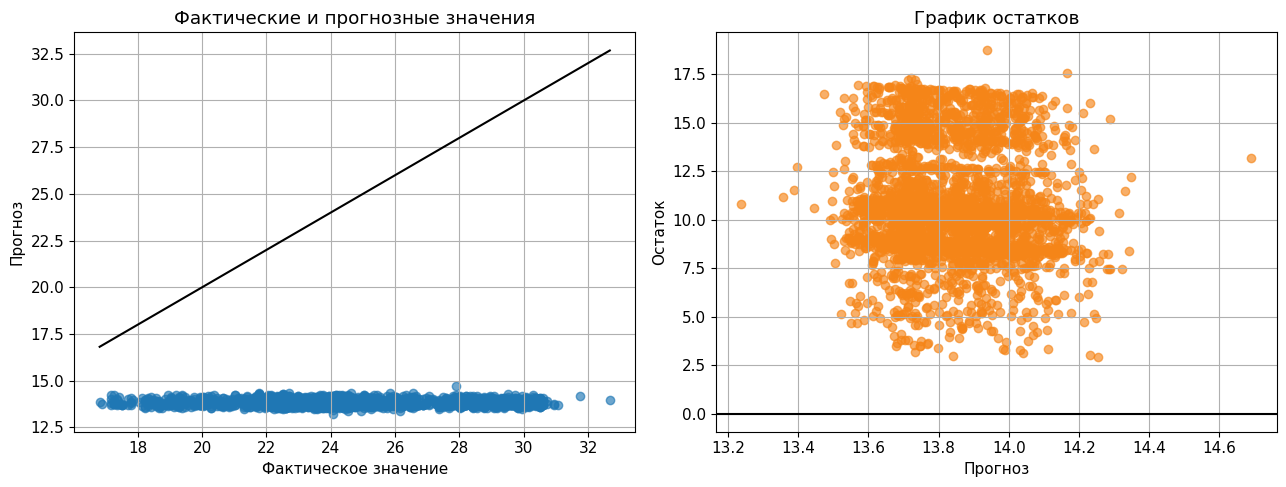

In [5]:
selected_pred = predictions["polynomial_ridge"]
residuals = y_test - selected_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, selected_pred, alpha=0.65)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black")
axes[0].set_xlabel("Фактическое значение")
axes[0].set_ylabel("Прогноз")
axes[0].set_title("Фактические и прогнозные значения")
axes[1].scatter(selected_pred, residuals, alpha=0.65, color="#f58518")
axes[1].axhline(0.0, color="black")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")
axes[1].set_title("График остатков")
plt.tight_layout()
plt.show()


## Демонстрация риска утечки данных

Ниже используется расширенный набор признаков, включающий диагностические или
расчетные столбцы. Если метрики резко улучшаются, результат нельзя считать
доказательством качества базовой модели: возможно, модель получила
информацию, недоступную в момент реального прогноза.


In [6]:
leakage_features = [column for column in ['speed_rpm', 'torque_proxy_nm', 'voltage_v', 'current_a', 'ambient_temp_c', 'temperature_c', 'T1', 'T2', 'T3'] if column in full_df.columns]
leakage_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=leakage_features + [regression_target]
).copy()
if len(leakage_features) >= 2 and len(leakage_df) > 20:
    train_idx_l, test_idx_l, _ = group_holdout_split(leakage_df, GROUP_COLUMN, test_share=0.25)
    leakage_model = Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])
    leakage_model.fit(leakage_df.loc[train_idx_l, leakage_features], leakage_df.loc[train_idx_l, regression_target])
    leakage_pred = leakage_model.predict(leakage_df.loc[test_idx_l, leakage_features])
    leakage_metrics = pd.Series(
        regression_metrics(leakage_df.loc[test_idx_l, regression_target], leakage_pred),
        name="leakage_demo",
    )
else:
    leakage_metrics = pd.Series(dtype=float, name="leakage_demo")
leakage_metrics.to_frame("value")


,value
MAE,5.568184
RMSE,7.063069
R2,-5.538914


In [7]:
experiment_degree = 2
experiment_alpha = 1.0
experiment_model = Pipeline([
    ("poly", PolynomialFeatures(degree=experiment_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=experiment_alpha)),
])
experiment_model.fit(X_train, y_train)
experiment_pred = experiment_model.predict(X_test)
pd.Series(regression_metrics(y_test, experiment_pred), name="experiment")


MAE     10.598671
RMSE    10.954110
R2     -14.727981
Name: experiment, dtype: float64

## Задание

1. Укажите целевую переменную и строгий набор признаков.
2. Объясните, почему применено разбиение по профилям или датам.
3. Сравните базовую модель, линейную регрессию и полиномиальную гребневую
   регрессию (Ridge regression).
4. Постройте график остатков и объясните систематические ошибки.
5. Отдельно опишите демонстрацию утечки данных.
